En este notebook evaluaré diferentes modelos de ML clásico a ciegas, usando el dataset original sin refinar para poder ver qué modelos pueden ser más prometedores para el trabajo.

~Santi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, f1_score, classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Pipeline de imblearn 
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC 

# Modelo principal explicable
from lightgbm import LGBMClassifier


SEED = 777
np.random.seed(SEED)

In [9]:
data = pd.read_excel("../data/raw/Dataset_v2_anonimizado.xlsx")

In [10]:
data.head()

,ID,Variable de Salida,Variable 01,Variable 02,Variable 03,Variable 04,Variable 05,Variable 06,Variable 07,Variable 08,...,Variable 92,Variable 93,Variable 94,Variable 95,Variable 96,Variable 97,Variable 98,Variable 99,Variable 100,Variable 101
0,1001,NOK,IZQUIERDA,EVENT TYPE G,3.0,6.0,13.0,7.95,17.123810,24.800001,...,N,48.000000,80,3,BR,2,27,80.83,77,BR
1,1002,NOK,DERECHA,EVENT TYPE G,2.0,6.0,13.0,5.50,17.166667,24.700000,...,N,48.066667,81,4,BR,1,28,47.37,74,BR
2,1003,NOK,IZQUIERDA,EVENT TYPE G,3.0,6.0,13.0,6.00,17.126087,24.800001,...,N,48.083333,82,5,BR,2,26,83.03,75,BR
3,1004,OK,DERECHA,EVENT TYPE G,3.0,6.0,13.0,5.50,17.152174,24.800001,...,N,48.116667,83,6,BR,0,28,47.53,74,BR
4,1005,NOK,IZQUIERDA,EVENT TYPE G,3.0,6.0,13.0,6.00,17.145455,24.800001,...,N,48.133333,84,7,BR,2,26,83.28,94,BR


In [11]:
data['Variable de Salida'] = data['Variable de Salida'].apply(lambda x: 0 if x == 'NOK' else 1)

# Eliminamos la variable Variable 02
data.drop(columns=['Variable 02', 'ID'], inplace=True)

# One-Hot Encoding 
categorical_columns = [i for i in data.columns if data[i].dtypes not in ['int64', 'float64']]
data_encoded = pd.get_dummies(columns=categorical_columns, data=data)

In [12]:
# Guardamos los datasets "básicos"
data_encoded.to_csv('../data/scaled/data_basic_10k.csv', index=False)

In [5]:
ruta_csv = '../data/scaled/data_basic_10k.csv' 
data = pd.read_csv(ruta_csv)

# Separamos Features y Target 
X = data.drop(columns=['Variable de Salida'])
y = data['Variable de Salida']

# mantenemos la proporción 4:1 en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=SEED, 
    stratify=y
)

print(f"Dimensiones de entrenamiento: {X_train.shape}")
print(f"Distribución en Target Train:\n{y_train.value_counts()}")

print("Dimensiones de test:", X_test.shape)
print(f"Distribución en Target Test:\n{y_test.value_counts()}")

Dimensiones de entrenamiento: (7996, 131)
Distribución en Target Train:
Variable de Salida
0    6046
1    1950
Name: count, dtype: int64
Dimensiones de test: (1999, 131)
Distribución en Target Test:
Variable de Salida
0    1511
1     488
Name: count, dtype: int64


In [ ]:

# 2. Identificamos columnas categóricas (One-Hot) para dárselas a SMOTENC
# Asumimos que las creadas con get_dummies o booleanas son categóricas
categorical_features_indices = [
    i for i, col in enumerate(X_train.columns) 
    if X_train[col].nunique() <= 2
]

# 3. Creación del Pipeline de Imblearn
# Con ImbPipeline , SMOTENC solo se aplicará al X_train de cada fold internamente, evitando el overfitting que se producia en el notebook 8. 
##SMOTENC trabaja de forma categórica para aquellos indices que le indiquemos y continua para el resto, en nuestro caso, categorical_features_indices. 
pipeline = ImbPipeline([
    ('smote', SMOTENC(categorical_features=categorical_features_indices, random_state=SEED)),
    ('classifier', LGBMClassifier(
        random_state=SEED, 
        n_jobs=-1,
        verbose=-1,
        device='gpu',
        gpu_platform_id=0, # Por defecto suele ser 0
        gpu_device_id=0   
    ))
])

In [9]:
# Validación cruzada estratificada de 5 particiones
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

#GRID DE PARÁMETROS
param_grid = {
    'smote__k_neighbors': [3, 5], # el numero de k vecinos más cercanos que SMOTENC usará para generar nuevas muestras sintéticas.
    'classifier__num_leaves': [15, 31, 50],     # Profundidad de árboles pequeña para evitar overfitting
    'classifier__learning_rate': [0.01, 0.05, 0.1] 
}

# Configuración del GridSearch
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    verbose=1
)

# si os fijais, le estamos dando los datos de inicio, y el oversampling se hará internamente en cada fold, evitando el overfitting.
grid.fit(X_train, y_train)

print(f"\nMejores hiperparámetros encontrados: {grid.best_params_}")
print(f"Mejor F1-Score en validación cruzada: {grid.best_score_:.4f}")

best_model = grid.best_estimator_

Fitting 5 folds for each of 18 candidates, totalling 90 fits


KeyboardInterrupt: 

📊 REPORTE DE CLASIFICACIÓN EN TEST (DATOS INVISIBLES):
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.77      0.96      0.85      1511
           1       0.48      0.11      0.18       488

    accuracy                           0.75      1999
   macro avg       0.62      0.54      0.52      1999
weighted avg       0.70      0.75      0.69      1999



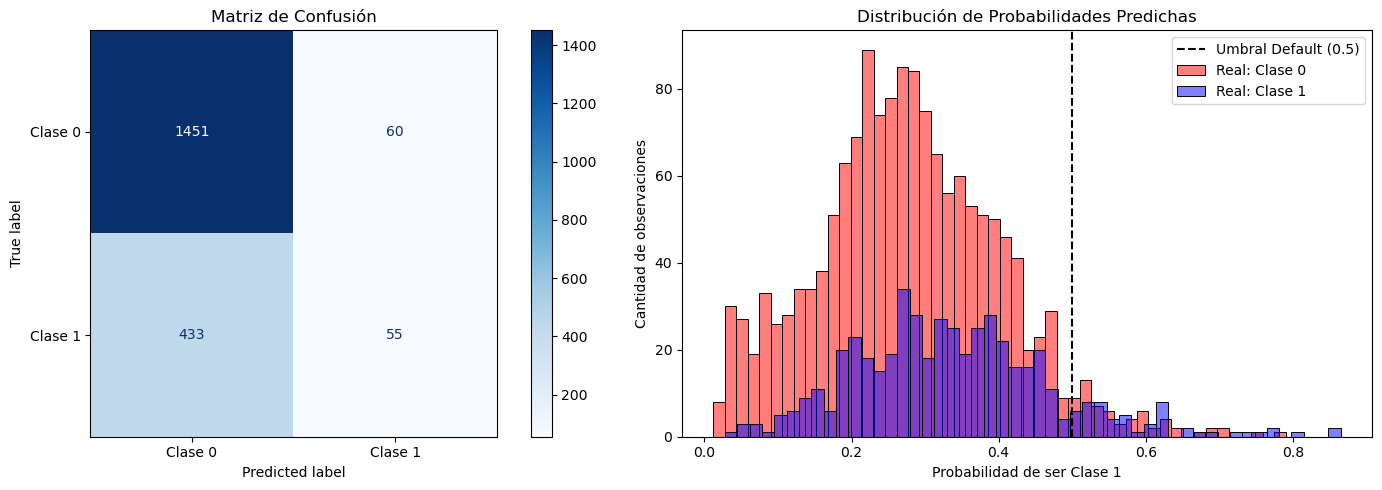

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Hacemos predicciones sobre el set de test que el modelo NUNCA ha visto
y_pred = best_model.predict(X_test)

# 2. Sacamos las probabilidades (para ver qué tan "seguro" está el modelo)
# [:, 1] nos da la probabilidad de que pertenezca a la clase 1
y_proba = best_model.predict_proba(X_test)[:, 1] 

# --- REPORTE NUMÉRICO ---
print("📊 REPORTE DE CLASIFICACIÓN EN TEST (DATOS INVISIBLES):")
print("-" * 55)
print(classification_report(y_test, y_pred))

# --- GRÁFICOS DE DIAGNÓSTICO ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Clase 0', 'Clase 1'])
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Matriz de Confusión')

# Gráfico 2: Histograma de Probabilidades
# Aquí vemos cómo el modelo separa los ceros de los unos
sns.histplot(y_proba[y_test == 0], bins=50, color='red', alpha=0.5, label='Real: Clase 0', ax=axes[1])
sns.histplot(y_proba[y_test == 1], bins=50, color='blue', alpha=0.5, label='Real: Clase 1', ax=axes[1])
axes[1].axvline(0.5, color='black', linestyle='--', label='Umbral Default (0.5)')
axes[1].set_title('Distribución de Probabilidades Predichas')
axes[1].set_xlabel('Probabilidad de ser Clase 1')
axes[1].set_ylabel('Cantidad de observaciones')
axes[1].legend()

plt.tight_layout()
plt.show()

El learning rate es un valor extremo, con lo que cogeremos ahora valores aún más pequeños. Además, la max_depth elegida por el grid search también es máxima. Esto significa que ante valores de profundidad más grande con este learning rate, el modelo tenderá al sobreaprendizaje. 

Esto nos da una pista muy importante: Son muchas variables para el modelo de clasificación, y si aumentamos la profundidad sin reducir el learning rate el modelo aprenderá reglas super específicas y absurdas. Entonces, hacemos un nuevo grid con menor lr pero más arboles y más profundidad para cada uno:

$$Prob_{final} = Prob_{inicial} + \eta(Ajuste_{1}) + \eta(Ajuste_{2}) + \dots + \eta(Ajuste_{n})$$

$\eta$ es el learning rate, por lo que si lo bajamos vamos a necesitar más ajustes, es decir, más estimators.

### PROBAMOS REDUCCIÓN DE VARIABLES, MENOR LR Y MAYOR PROFUNDIDAD DE ÁRBOL.

Para la reducción de variables, voy a usar mutual information. Creo que la habéis dado en no supervisada pero no lo sé (?). Capta correlaciones pero de forma también no lineal.


In [9]:

# Definimos el Pipeline reactivo ante los resultados anteriores (añadiendo un filtro de ruido con SelectKBest)

reactive_pipeline = ImbPipeline([
    ('smote', SMOTENC(categorical_features=categorical_features_indices, random_state=SEED)),
    ('selector', SelectKBest(score_func=mutual_info_classif)), # <-- El filtro de ruido
    ('classifier', LGBMClassifier(
        random_state=SEED, 
        class_weight='balanced',
        n_jobs=-1,
        verbose=-1
    ))
])

# Nueva Rejilla de Hiperparámetros
reactive_param_grid = {
    'selector__k': [20, 40, 60],              # Cuántas variables son útiles realmente
    'smote__k_neighbors': [3, 5],
    'classifier__n_estimators': [500, 1000],  # Más árboles porque el paso de aprendizaje es más corto
    'classifier__learning_rate': [0.005, 0.01],# Pasos de aprendizaje muy finos
    'classifier__max_depth': [5, 7]           # Un poco más de margen de profundidad
}

# GridSearch (Esto tardará un poco más por el SelectKBest)
reactive_grid = GridSearchCV(
    estimator=reactive_pipeline,
    param_grid=reactive_param_grid,
    scoring=f1_clase_0, # Seguimos enfocados en la clase OK
    cv=cv,
    n_jobs=-1,
    verbose=1
)

print("Iniciando búsqueda reactiva... ")
reactive_grid.fit(X_train, y_train)

print(f"\n--- RESULTADOS ---")
print(f"Mejor número de variables (K): {reactive_grid.best_params_['selector__k']}")
print(f"Mejores parámetros: {reactive_grid.best_params_}")
print(f"Nuevo F1-Score (Clase 0) en CV: {reactive_grid.best_score_:.4f}")


# Guardamos este modelo como el definitivo para las pruebas de umbral
best_reactive_model = reactive_grid.best_estimator_

Iniciando búsqueda reactiva... 
Fitting 5 folds for each of 48 candidates, totalling 240 fits

--- RESULTADOS ---
Mejor número de variables (K): 20
Mejores parámetros: {'classifier__learning_rate': 0.005, 'classifier__max_depth': 5, 'classifier__n_estimators': 500, 'selector__k': 20, 'smote__k_neighbors': 3}
Nuevo F1-Score (Clase 0) en CV: 0.3630


Vale, los resultados son ligeramente decepcionantes. Sin embargo, la mejor combinación se ha dado con 20 variables en vez de 112 y eso es un notición. Con 20 variables el modelo es mucho más fácil de explicar y más eficiente computacionalmente.

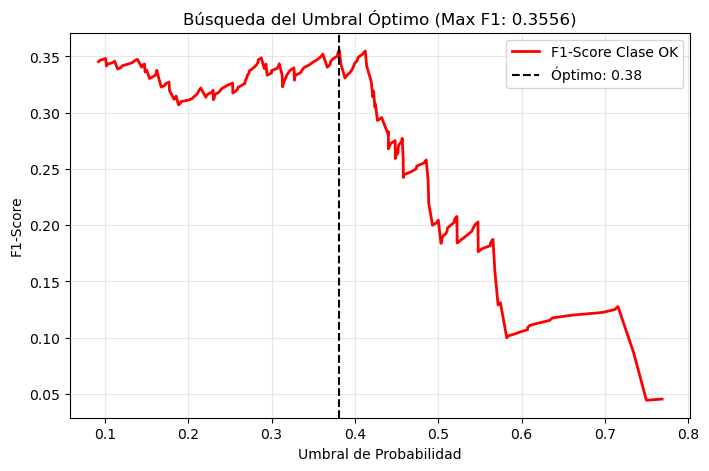

El umbral que maximiza el F1 es 0.38 con un F1 de 0.3556


In [11]:
from sklearn.metrics import precision_recall_curve

# Sacamos probabilidades del nuevo modelo mejorado
y_probs = best_reactive_model.predict_proba(X_test)[:, 0] # Probabilidad de clase 0 (OK)

# Calculamos precisión, recall y umbrales
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs, pos_label=0)

# Calculamos F1 para cada umbral
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = np.max(f1_scores)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores[:-1], label='F1-Score Clase OK', color='red', lw=2)
plt.axvline(best_threshold, color='black', linestyle='--', label=f'Óptimo: {best_threshold:.2f}')
plt.title(f'Búsqueda del Umbral Óptimo (Max F1: {best_f1:.4f})')
plt.xlabel('Umbral de Probabilidad')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"El umbral que maximiza el F1 es {best_threshold:.2f} con un F1 de {best_f1:.4f}")